In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

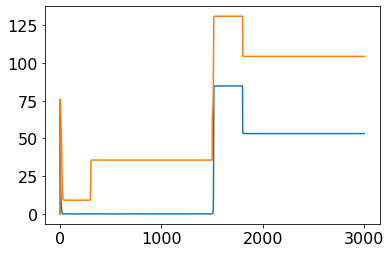

[[9.9409e-03 3.5642e+01]
 [5.3253e+01 1.0443e+02]]


In [9]:
aln = ALNModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# NO ADAPTATION => else no bistability
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

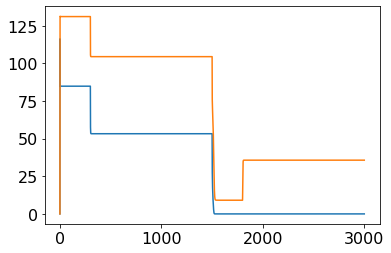

In [10]:
aln.params['duration'] = 3000.
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.99
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-2] * 0.99  

In [11]:
max_it = 5
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 10.
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

In [12]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]

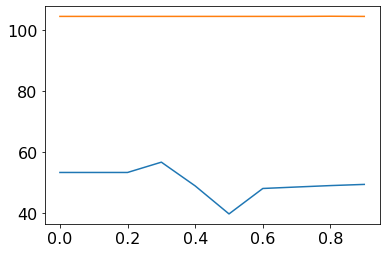

In [94]:
dur = 0.9
dur_pre = 0.5
dur_post = 0.5
aln.params.duration = dur

# no delay
aln.params.signalV = 0.
aln.params.de = 0.2
aln.params.di = 0.3

setinitvars(high_state_vars)

control0 = aln.getZeroControl()

######## A1 outperforms A2, but gradient is large
control0[:,0,2] += 1.
control0[:,0,3] -= 2.
control0[:,0,4] -= 3.
control0[:,0,5] += 3.

#control0[:,1,2] += 2.
#control0[:,1,4] -= 3.

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

# set high state rates as target
target = aln.getZeroTarget()
target[:,0,:] = aln.rates_exc[0,:]
target[:,1,:] = aln.rates_inh[0,:]

set cost params
RUN  0 , total integrated cost =  14.987526158684481
RUN  1 , total integrated cost =  5.653732870900866
RUN  2 , total integrated cost =  2.2093974177503233
RUN  3 , total integrated cost =  1.7896904881266957
RUN  4 , total integrated cost =  1.583908215159317
RUN  5 , total integrated cost =  1.479802787317111
RUN  6 , total integrated cost =  1.3867379707755032
RUN  7 , total integrated cost =  1.3121404922461846
RUN  8 , total integrated cost =  1.2509230450550701
RUN  9 , total integrated cost =  1.2033192804986754
RUN  10 , total integrated cost =  1.153901850494954
RUN  11 , total integrated cost =  1.1133644956243347
RUN  12 , total integrated cost =  1.0815610274749607
RUN  13 , total integrated cost =  1.0528409165796404
RUN  14 , total integrated cost =  1.035146463140014
RUN  15 , total integrated cost =  1.0194611293778089
RUN  16 , total integrated cost =  1.0062529953710126
RUN  17 , total integrated cost =  0.9947320361657466
RUN  18 , total integrated 

ERROR:root:Problem in initial value trasfer


RUN  93 , total integrated cost =  0.8943371269436396
RUN  94 , total integrated cost =  0.8943370596472123
RUN  95 , total integrated cost =  0.8943360958713896
RUN  96 , total integrated cost =  0.8943339980145144
RUN  97 , total integrated cost =  0.8943338936458072
RUN  98 , total integrated cost =  0.8943337343701315
RUN  99 , total integrated cost =  0.8943322415204675
RUN  100 , total integrated cost =  0.8943318363864463
Improved over  100  iterations by  94.0328255182512  percent.
Problem in initial value trasfer:  Vmean_exc -56.701802018691225 -56.70214648546198
grad =  [[[ 0.00000000e+00  7.23093621e-02  7.21092654e-02  1.05335560e-01
    3.52087466e-02 -2.56019235e-03  2.53457555e-02  6.72907206e-03
    5.89163992e-03  0.00000000e+00]
  [ 0.00000000e+00  2.89125888e-05  7.79016986e-05  1.74557044e-04
    2.27298664e-04  4.55089709e-04  4.24238613e-04  6.88312355e-04
    4.50025100e-04  0.00000000e+00]]]


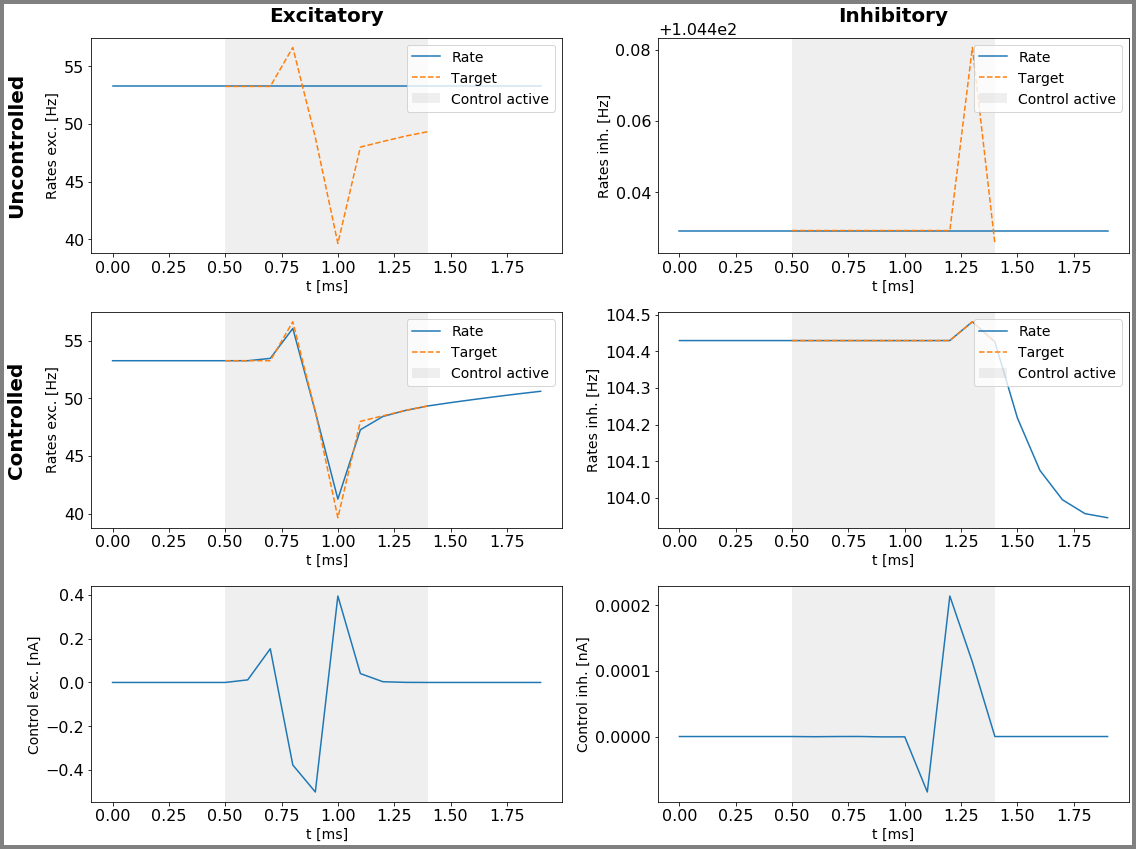

In [123]:
cost.setParams(1.0, 1., 0.0)
max_cntrl = 100. * 5.

setinitvars(high_state_vars)
max_it = 100
alg = "A1"
case = "A"

aln.params.duration = dur
control0 = aln.getZeroControl()
control1 = bestControlA[:,:,5:15]
#control1[0,1,:4] = bestControlA2[:,1,5:9]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))

print("grad = ", grad)

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)

set cost params
cost precision =  14.987526158684481
cost energy =  0.0
cost sparsity =  0.0
RUN  0 , total integrated cost:  14.987526158684481
1.0 1.0 0.0
no sparsity,  0 0 0
get dir 
cost precision =  14.987526158684481
cost energy =  0.0
cost sparsity =  0.0
cost precision =  14.987533205373053
cost energy =  5e-14
cost sparsity =  0.0
cost precision =  14.987526158684481
cost energy =  0.0
cost sparsity =  0.0
cost precision =  14.987519112000431
cost energy =  5e-14
cost sparsity =  0.0
get step
cost precision =  14.987526158684481
cost energy =  0.0
cost sparsity =  0.0
cost precision =  365.809990764187
cost energy =  5.0
cost sparsity =  0.0
step, cost, initial cost =  10.0 370.809990764187 14.987526158684481
cost precision =  53.73343318554714
cost energy =  1.25
cost sparsity =  0.0
step, cost, initial cost =  5.0 54.98343318554714 14.987526158684481
cost precision =  13.179113161207459
cost energy =  0.3125
cost sparsity =  0.0
step, cost, initial cost =  2.5 13.49161316120

ERROR:root:Problem in initial value trasfer


cost energy =  0.04997625298207578
cost sparsity =  0.0
step, cost, initial cost =  0.3125 2.6619726206617003 3.191144342961123
cost precision =  2.516947067371347
cost energy =  0.2053858388986944
cost sparsity =  0.0
cost precision =  2.5147591577061283
cost energy =  0.020703128670342824
cost sparsity =  0.0
cost precision =  2.526335812070706
cost energy =  0.017382816170342826
cost sparsity =  0.0
step size =  (0.5625, 2.5354622863764713)
no sparsity,  5 0 1
get dir 
cost precision =  2.5147591577061283
cost energy =  0.2808833567312368
cost sparsity =  0.0
cost precision =  2.5147586982671526
cost energy =  0.015820312500100003
cost sparsity =  0.0
cost precision =  2.5147591577061283
cost energy =  0.2808833567312368
cost sparsity =  0.0
cost precision =  2.5147596171625115
cost energy =  0.01582034654741214
cost sparsity =  0.0
get step
cost precision =  2.5147591577061283
cost energy =  0.2808833567312368
cost sparsity =  0.0
cost precision =  496.0372074214304
cost energy =  

ERROR ---------------- in index  1


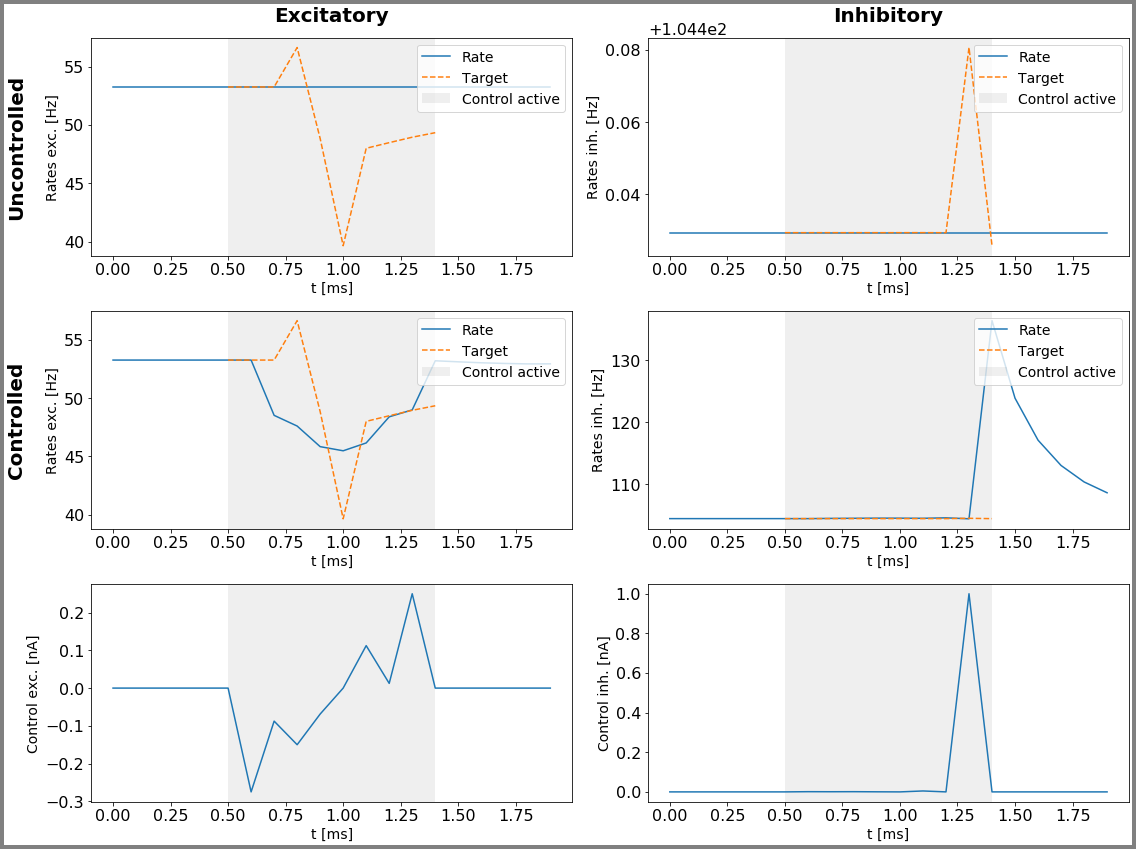

In [136]:
cost.setParams(1.0, 1., 0.0)

setinitvars(high_state_vars)
max_it = 1
alg = "A2"
case = "A"

aln.params.duration = dur
control0 = aln.getZeroControl()
control1 = bestControlA2[:,:,5:15]

bestControlA2, bestStateA2, costA2, runtimeA2 = aln.A2(control0, target, max_iteration_ = max_it,
                tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

plotFunc.plot_control(aln, bestControlA2, dur, dur_pre, dur_post, high_state_vars, target,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))


for i in range(1, len(costA2)):
    if costA2[i-1] < costA2[i]:
        print("ERROR ---------------- in index ", i)

[[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00 -1.43429934e+00 -1.20749045e+00
    1.13720811e+00  2.16170434e+00 -1.47788675e+00 -2.02219885e-01
   -1.11153238e-03 -4.00210605e+00  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00  5.37252764e-03  3.90520629e-03
    5.37108213e-03  2.19746504e-03  3.90684930e-02  4.17393312e-04
   -3.50826906e-03 -5.69495031e-04  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]]]


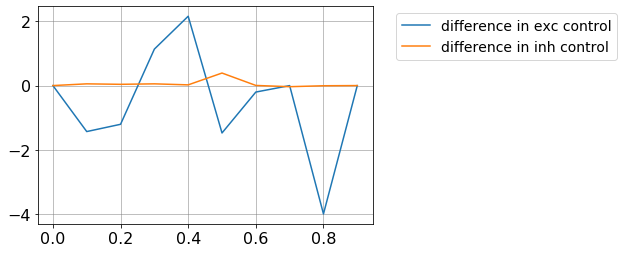

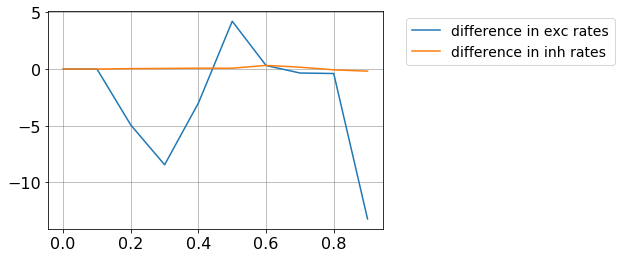

In [117]:
diff = bestControlA2 - bestControlA
diff_state = bestStateA2 - bestStateA

diff[:,:,0] = 0
diff[:,:,-1] = 0

sparsitygradientinh = np.array( [ 0.,9.49932197e-02,3.44809490e+00,-3.02161508e-02,-5.29884978e+00,
    -1.51166411e-01,-6.67096985e-03,-6.46825813e-05,-2.28743628e-04,0. ] )
adjointgradientinh = np.array( [ 0.,-9.49924781e-02,-3.44809399e+00,3.02175014e-02,5.29885118e+00,
     1.51167334e-01,6.67158491e-03,6.52247394e-05,2.28994155e-04,0. ] )

print(diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,5:15], label="difference in exc control")
plt.plot(t, 1e1 *diff[0,1,5:15], label="difference in inh control")
#plt.plot(t, bestControlA[0,1,5:15], label="inh control")
#plt.plot(t, - 1e0 * grad[0,0,:], label="grad exc")
#plt.plot(t, - 1e0 * grad[0,1,:], label="grad inh")
#plt.plot(t, - 1e0 *sparsitygradientinh, label = "sparsity grad")
#plt.plot(t, - 1e0 * adjointgradientinh, label = "adjoint grad")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff_state[0,0,5:15], label="difference in exc rates")
plt.plot(t, diff_state[0,1,5:15], label="difference in inh rates")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()